In [485]:
import pandas as pd
import numpy as np
from datetime import datetime
from IPython.display import display, HTML

=====================================
## CAMADA BRONZE
=====================================

In [486]:

url = "https://github.com/Nina-Da-Hora/analise-estrategica-marcas-automotivas/releases/download/v1.0/car_prices_dataset.zip"

df_bronze = pd.read_csv(url, compression="zip")

# salvar
df_bronze.to_csv("car_prices_bronze.csv", index=False)

print("Bronze criado com sucesso.")
print("Linhas:", df_bronze.shape[0])
print("Colunas:", df_bronze.shape[1])

Bronze criado com sucesso.
Linhas: 558837
Colunas: 16


======================================
## Análise Exploratória  Dados Brutos
======================================

In [487]:
df = pd.read_csv("car_prices_bronze.csv")
df.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5,"16,639",white,black,kia motors america inc,"20,500","21,500",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5,"9,393",white,beige,kia motors america inc,"20,800","21,500",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45,"1,331",gray,black,financial services remarketing (lease),"31,900","30,000",Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41,"14,282",white,black,volvo na rep/world omni,"27,500","27,750",Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43,"2,641",gray,black,financial services remarketing (lease),"66,000","67,000",Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


======================================
## Análise de Completude (Nulos)
======================================

In [488]:

total_linhas = len(df)

total_celdas = df.size
total_nulos = df.isna().sum().sum()
porcentaje_nulos = round((total_nulos / total_celdas) * 100, 2)

resumen_dataset = pd.DataFrame({
    "Total de Registros": [total_linhas],
    "Total de Celdas": [total_celdas],
    "Total de Nulos": [total_nulos],
    "% de Nulos": [porcentaje_nulos]
})

print("-------------------------------------")
print("\n Identificação de nulos do dataset")
display(resumen_dataset)

df_info = pd.DataFrame({
    "Coluna": df.columns,
    "Total Registros": total_linhas,
    "Não Nulos": df.notna().sum().values,
    "Nulos": df.isna().sum().values,
    "% Nulos": (df.isna().sum().values / total_linhas * 100).round(2)
})

df_info = df_info.sort_values("% Nulos", ascending=False)

limite_alerta = 15
df_info["Alerta"] = df_info["% Nulos"].apply(lambda x: "Revisar" if x > limite_alerta else "")

df_info.index = range(1, len(df_info) + 1)

print("-------------------------------------")
print("\n Identificação de nulos por colunas")
display(df_info)


-------------------------------------

 Identificação de nulos do dataset


,Total de Registros,Total de Celdas,Total de Nulos,% de Nulos
0,558837,8941392,123376,1


-------------------------------------

 Identificação de nulos por colunas


,Coluna,Total Registros,Não Nulos,Nulos,% Nulos,Alerta
1,transmission,558837,493485,65352,12,
2,body,558837,545642,13195,2,
3,condition,558837,547017,11820,2,
4,trim,558837,548186,10651,2,
5,model,558837,548438,10399,2,
6,make,558837,548536,10301,2,
7,color,558837,558088,749,0,
8,interior,558837,558088,749,0,
9,odometer,558837,558743,94,0,
10,mmr,558837,558799,38,0,


====================================
## Análise da Estrutura dos Dados
====================================

In [489]:

df_tipos = pd.DataFrame({
    "Coluna": df.columns,
    "Tipo Atual": df.dtypes.values,
    "Valores Únicos": [df[col].nunique(dropna=True) for col in df.columns]
})

df_tipos["Alerta"] = df_tipos.apply(
    lambda row: "Revisar" if (row["Tipo Atual"] == 'object' and row["Valores Únicos"] < 10) else "",
    axis=1
)

# Ajustar índice
df_tipos.index = range(1, len(df_tipos) + 1)

df_tipos

,Coluna,Tipo Atual,Valores Únicos,Alerta
1,year,int64,34,
2,make,object,96,
3,model,object,973,
4,trim,object,1963,
5,body,object,87,
6,transmission,object,4,Revisar
7,vin,object,550297,
8,state,object,64,
9,condition,float64,41,
10,odometer,float64,172278,


====================================
## Análise de duplicados (Unicidade)
====================================


In [490]:

filas_duplicadas = df.duplicated().sum()
df_filas_duplicadas = pd.DataFrame({
"Linhas Totais": [total_linhas],
"Linhas Duplicadas": [filas_duplicadas],
"Linhas Únicas": [total_linhas - filas_duplicadas],
"Percentual Duplicadas (%)": [round(filas_duplicadas / total_linhas * 100, 2)],
"Percentual Únicas (%)": [round((total_linhas - filas_duplicadas) / total_linhas * 100, 2)] })

print("\n Identificação de linhas duplicadas")
display(df_filas_duplicadas)


 Identificação de linhas duplicadas


,Linhas Totais,Linhas Duplicadas,Linhas Únicas,Percentual Duplicadas (%),Percentual Únicas (%)
0,558837,0,558837,0,100


==========================================
##Análise de Consistência dos Dados
==========================================

In [491]:

df_temp = df.copy()

df_temp["saledate"] = pd.to_datetime(
    df_temp["saledate"].str.replace(r" GMT.*", "", regex=True),
    format="%a %b %d %Y %H:%M:%S",
    errors="coerce"
)

df_temp = df_temp.dropna(subset=["saledate"])
df_temp["sale_year"] = df_temp["saledate"].dt.year

  #Venda posterior ou igual ao ano do veículo
ano_inconsistente = df_temp[df_temp["sale_year"] < (df_temp["year"]-1)].shape[0]

  # Preço menor que 0
precio_invalidos = df_temp[df_temp["sellingprice"] <= 0].shape[0]

  # Odômetro não negativo
odometro_invalidos = df_temp[df_temp["odometer"] < 0].shape[0]

  # Preço de venda dentro de um intervalo razoável do MMR
precio_sospechoso = df_temp[
      abs(df_temp["sellingprice"] - df_temp["mmr"]) > df_temp["mmr"] * 2
  ].shape[0]

df_consistencia = pd.DataFrame({
      "Regra de Consistência": [
          "Venda posterior ou igual ao ano do veículo",
          "Preço maior que 0",
          "Odômetro não negativo",
          "Preço de venda dentro de um intervalo razoável do MMR"
      ],
      "Registros inconsistentes": [
          ano_inconsistente,
          precio_invalidos,
          odometro_invalidos,
          precio_sospechoso
      ],
      "Porcentaje (%)": [
          round(ano_inconsistente / total_linhas * 100, 2),
          round(precio_invalidos / total_linhas * 100, 2),
          round(odometro_invalidos / total_linhas * 100, 2),
          round(precio_sospechoso / total_linhas * 100, 2)
      ]
  })
print("-------------------------------------")
print("\n Identificação de inconsistências")
df_consistencia


-------------------------------------

 Identificação de inconsistências


,Regra de Consistência,Registros inconsistentes,Porcentaje (%)
0,Venda posterior ou igual ao ano do veículo,0,0
1,Preço maior que 0,0,0
2,Odômetro não negativo,0,0
3,Preço de venda dentro de um intervalo razoável...,706,0


In [492]:
df['transmission'].unique()

array(['automatic', nan, 'manual', 'Sedan', 'sedan'], dtype=object)

====================================
## Análise de Valores Zerados
====================================

In [493]:
linhas, colunas = df.shape
total_celulas = linhas * colunas
total_nulos = df.isna().sum().sum()
percentual_nulos = round((total_nulos / total_celulas) * 100, 2)
alerta = "Alto % de nulos" if percentual_nulos > 5 else ""

df_integridade_horizontal = pd.DataFrame([{
    "Linhas": linhas,
    "Colunas": colunas,
    "Total de Células": total_celulas,
    "Total de Nulos": total_nulos,
    "Percentual de Nulos (%)": percentual_nulos,
    "Alerta": alerta
}])

df_integridade_horizontal

,Linhas,Colunas,Total de Células,Total de Nulos,Percentual de Nulos (%),Alerta
0,558837,16,8941392,123376,1,


========================================================
## Verificação de integridade para colunas numéricas
========================================================

In [494]:

num_cols = df.select_dtypes(include="number").columns

resumo_num = []

for col in num_cols:
    negativos = (df[col] < 0).sum()
    percentual_negativos = round(negativos / total_linhas * 100, 2)
    alerta = "Atenção" if negativos > 0 else ""

    resumo_num.append({
        "Coluna": col,
        "Total_Negativos": negativos,
        "% Negativos": percentual_negativos,
        "Alerta": alerta
    })

df_resumo_num = pd.DataFrame(resumo_num)
df_resumo_num

,Coluna,Total_Negativos,% Negativos,Alerta
0,year,0,0,
1,condition,0,0,
2,odometer,0,0,
3,mmr,0,0,
4,sellingprice,0,0,


========================================================
## Verificação de integridade para colunas categóricas
========================================================

In [495]:

cat_cols = df.select_dtypes(include="object").columns
resumo_cat = []

for col in cat_cols:
    valores_unicos = df[col].nunique(dropna=True)
    alerta = "Revisar" if valores_unicos > 10 else ""

    resumo_cat.append({
        "Coluna": col,
        "Valores Únicos": valores_unicos,
        "Alerta": alerta
    })

df_resumo_cat = pd.DataFrame(resumo_cat)
df_resumo_cat = df_resumo_cat.sort_values("Valores Únicos", ascending=False).reset_index(drop=True)
df_resumo_cat

,Coluna,Valores Únicos,Alerta
0,vin,550297,Revisar
1,seller,14263,Revisar
2,saledate,3766,Revisar
3,trim,1963,Revisar
4,model,973,Revisar
5,make,96,Revisar
6,body,87,Revisar
7,state,64,Revisar
8,color,46,Revisar
9,interior,17,Revisar


========================================================
## Correlação entre todas as colunas numéricas
========================================================

Cada célula mostra o coeficiente de correlação de Pearson entre duas colunas
O valor varia de -1 a 1:

1 → correlação perfeita positiva (quando uma aumenta, a outra aumenta na mesma proporção)

-1 → correlação perfeita negativa (quando uma aumenta, a outra diminui na mesma proporção)

0 → nenhuma correlação linear clar

In [496]:

df.corr(numeric_only=True)

,year,condition,odometer,mmr,sellingprice
year,1,0,-1,1,1
condition,0,1,-0,0,0
odometer,-1,-0,1,-1,-1
mmr,1,0,-1,1,1
sellingprice,1,0,-1,1,1


======================================
## Análise de Consistência Temporal
======================================

In [497]:
ano_min_aceitavel = 1982
ano_max_aceitavel = 2015

anos_min = df["year"].min()
anos_max = df["year"].max()
anos_unicos = df["year"].nunique()

# Crear DataFrame resumido
df_resumo_anos = pd.DataFrame({
    "Métrica": ["Ano mínimo", "Ano máximo", "Total anos únicos"],
    "Valor": [anos_min, anos_max, anos_unicos],
    "Alerta": [
        "Fora de faixa" if anos_min < ano_min_aceitavel or anos_min > ano_max_aceitavel else "",
        "Fora de faixa" if anos_max < ano_min_aceitavel or anos_max > ano_max_aceitavel else "",
        ""
    ]
})

df_resumo_anos

,Métrica,Valor,Alerta
0,Ano mínimo,1982,
1,Ano máximo,2015,
2,Total anos únicos,34,


==================================
## Análise de Valores Atípicos na Coluna de Odômetro
==================================

In [498]:
# Cálculo de outliers usando IQR
Q1 = df['odometer'].quantile(0.25)
Q3 = df['odometer'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['odometer'] < limite_inferior) | (df['odometer'] > limite_superior)]

# Crear resumen como DataFrame
df_outliers_odometer = pd.DataFrame([{
    "Métrica": "Outliers de Odômetro",
    "Total_Outliers": len(outliers),
    "Percentual (%)": round(len(outliers) / len(df) * 100, 2),
    "Valor Mínimo Outlier": outliers['odometer'].min() if len(outliers) > 0 else None,
    "Valor Máximo Outlier": outliers['odometer'].max() if len(outliers) > 0 else None,
    "Limite Inferior": limite_inferior,
    "Limite Superior": limite_superior
}])

df_outliers_odometer

,Métrica,Total_Outliers,Percentual (%),Valor Mínimo Outlier,Valor Máximo Outlier,Limite Inferior,Limite Superior
0,Outliers de Odômetro,10375,2,"205,220","999,999","-77,736","205,216"


=====================================================
## Análise Específica – sellingprice - Nulos e Zeros
=====================================================

In [499]:
nulos = df["sellingprice"].isna().sum()
zeros = (df["sellingprice"] == 0).sum()
df_sellingprice_qualidade = pd.DataFrame({
     "Métrica": ["Nulos", "Zeros", "Total Problemáticos"],
     "Quantidade": [nulos, zeros, nulos + zeros],
     "Percentual (%)": [ round(nulos/total_linhas*100, 2),
                        round(zeros/total_linhas*100, 2),
                         round((nulos+zeros)/total_linhas*100, 2) ] })

df_sellingprice_qualidade

,Métrica,Quantidade,Percentual (%)
0,Nulos,12,0
1,Zeros,0,0
2,Total Problemáticos,12,0


================================================
## Análise Específica – sellingprice - Outliers
================================================

In [500]:

precos = df["sellingprice"].dropna()

Q1 = precos.quantile(0.25)
Q3 = precos.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = precos[precos > limite_superior]

df_outliers_sellingprice = pd.DataFrame([{
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "Limite Superior": limite_superior,
    "Total_Outliers": len(outliers),
    "Percentual_Outliers (%)": round(len(outliers)/len(df)*100, 2)
}])

df_outliers_sellingprice

,Q1,Q3,IQR,Limite Superior,Total_Outliers,Percentual_Outliers (%)
0,"6,900","18,200","11,300","35,150",16354,3


======================================
## Resumo estatístico do sellingprice
======================================

In [501]:
resumo = df["sellingprice"].describe()

df_resumo = pd.DataFrame([resumo])

for col in df_resumo.columns:
    df_resumo[col] = df_resumo[col].map(lambda x: f"${x:,.2f}")

df_resumo

,count,mean,std,min,25%,50%,75%,max
sellingprice,"$558,825.00","$13,611.36","$9,749.50",$1.00,"$6,900.00","$12,100.00","$18,200.00","$230,000.00"


=========================
## CAMADA SILVER
=========================

In [502]:

dfsilver = df_bronze.copy()

======================================
## Seleção e renomeação de colunas
======================================

In [503]:
# Selecionar colunas necessárias
df_silver = dfsilver[[
"vin",
"year",
"make",
"model",
"body",
"state",
"condition",
"odometer",
"mmr",
"sellingprice",
"saledate"
]]

#Renomear colunas
df_silver = df_silver.rename(columns={
"vin": "chassi",
"year":"ano",
"make":"marca",
"model":"modelo",
"body": "carroceria",
"state":"estado",
"condition":"condicao",
"odometer":"odometro",
"mmr":"preco_mmr",
"sellingprice":"preco_venda",
"saledate":"data_venda"
})

In [504]:
df_silver.head()

,chassi,ano,marca,modelo,carroceria,estado,condicao,odometro,preco_mmr,preco_venda,data_venda
0,5xyktca69fg566472,2015,Kia,Sorento,SUV,ca,5,"16,639","20,500","21,500",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,5xyktca69fg561319,2015,Kia,Sorento,SUV,ca,5,"9,393","20,800","21,500",Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,wba3c1c51ek116351,2014,BMW,3 Series,Sedan,ca,45,"1,331","31,900","30,000",Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,yv1612tb4f1310987,2015,Volvo,S60,Sedan,ca,41,"14,282","27,500","27,750",Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,wba6b2c57ed129731,2014,BMW,6 Series Gran Coupe,Sedan,ca,43,"2,641","66,000","67,000",Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


==================
# Coluna Chassi
==================


In [505]:
def limpar_vin(df, coluna_chassi='chassi'):

    df = df.copy()

    df = df[df[coluna_chassi].notna()]

    df[coluna_chassi] = df[coluna_chassi].astype(str).str.strip().str.upper()

    df = df[df[coluna_chassi].str.len() == 17]

    df = df.drop_duplicates(subset=coluna_chassi, keep='first')

    return df

In [506]:
df_silver = limpar_vin(df_silver)

total_inicial = dfsilver.shape[0]
total_final = df_silver.shape[0]

vin_nulos = dfsilver["vin"].isna().sum()

df_temp = dfsilver.copy()
df_temp["vin"] = df_temp["vin"].astype(str).str.strip().str.upper()

vin_invalidos = df_temp[df_temp["vin"].str.len() != 17].shape[0]

df_validos = df_temp[df_temp["vin"].str.len() == 17]
vin_duplicados = df_validos.duplicated(subset="vin").sum()

total_eliminados = total_inicial - total_final

resumo_vin = pd.DataFrame([{
    "VIN nulos": vin_nulos,
    "VIN inválidos": vin_invalidos,
    "VIN duplicados": vin_duplicados,
    "Total eliminados": total_eliminados,
    "Registros restantes": total_final
}])

# Mostrar
resumo_vin

,VIN nulos,VIN inválidos,VIN duplicados,Total eliminados,Registros restantes
0,4,26,8515,8541,550296


====================
# Coluna Ano
====================


In [507]:
def limpar_ano(df, ano_col='ano', ano_min=1980):

    df = df.copy()

    ano_max = datetime.now().year + 1  # dinámico

    df[ano_col] = pd.to_numeric(df[ano_col], errors='coerce')

    df = df[
        (df[ano_col].notna()) &
        (df[ano_col] >= ano_min) &
        (df[ano_col] <= ano_max)
    ]

    return df


In [508]:
def validar_ano(df, ano_col='ano', ano_min=1980):

    from datetime import datetime

    ano_max = datetime.now().year + 1

    df_temp = df.copy()
    df_temp[ano_col] = pd.to_numeric(df_temp[ano_col], errors='coerce')

    fuera_rango = df_temp[
        (df_temp[ano_col].isna()) |
        (df_temp[ano_col] < ano_min) |
        (df_temp[ano_col] > ano_max)
    ]

    return fuera_rango

In [509]:
df_silver.columns

Index(['chassi', 'ano', 'marca', 'modelo', 'carroceria', 'estado', 'condicao',
       'odometro', 'preco_mmr', 'preco_venda', 'data_venda'],
      dtype='object')

In [510]:
validar_ano(df_silver)

,chassi,ano,marca,modelo,carroceria,estado,condicao,odometro,preco_mmr,preco_venda,data_venda


In [511]:
df_silver = limpar_ano(df_silver,ano_col='ano')

=========================
# Coluna marca
=========================


In [512]:
marca_unicos = df_silver['marca'].unique()
print(marca_unicos)

['Kia' 'BMW' 'Volvo' 'Nissan' 'Chevrolet' 'Audi' 'Ford' 'Hyundai' 'Buick'
 'Cadillac' 'Acura' 'Lexus' 'Infiniti' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Mazda' 'MINI' 'Land Rover' 'Lincoln' 'lincoln' 'Jaguar' 'Volkswagen'
 'Toyota' 'Subaru' 'Scion' 'Porsche' nan 'bmw' 'Dodge' 'FIAT' 'Chrysler'
 'ford' 'Ferrari' 'Honda' 'GMC' 'mitsubishi' 'Ram' 'smart' 'chevrolet'
 'Bentley' 'chrysler' 'pontiac' 'Pontiac' 'Saturn' 'Maserati' 'Mercury'
 'HUMMER' 'landrover' 'cadillac' 'land rover' 'mercedes' 'mazda' 'toyota'
 'lexus' 'gmc truck' 'honda' 'nissan' 'porsche' 'Saab' 'Suzuki' 'dodge'
 'subaru' 'Oldsmobile' 'oldsmobile' 'hyundai' 'jeep' 'Isuzu' 'dodge tk'
 'Geo' 'acura' 'volkswagen' 'suzuki' 'kia' 'audi' 'Rolls-Royce' 'gmc'
 'maserati' 'mazda tk' 'mercury' 'buick' 'hyundai tk' 'mercedes-b' 'vw'
 'Daewoo' 'chev truck' 'ford tk' 'plymouth' 'Plymouth' 'ford truck'
 'Tesla' 'airstream' 'dot' 'Aston Martin' 'Fisker' 'Lamborghini' 'Lotus']


In [513]:
def tratamento_marcas(df, col_coluna='marca'):

    df = df.copy()

    # Eliminar nulos da coluna
    df = df.dropna(subset=[col_coluna])

    # Tratamento inicial: espaços e minúsculas
    df[col_coluna] = df[col_coluna].astype(str).str.strip().str.lower()

    # Correções diretas
    correcoes_diretas = {
        'landrover': 'land rover',
        'vw': 'volkswagen',
        'mercedes-b': 'mercedes-benz',
        'mercedes': 'mercedes-benz',
        'chev truck': 'chevrolet',
        'chev': 'chevrolet',
        'chevy': 'chevrolet',
        'infinit': 'infiniti'
    }
    df[col_coluna] = df[col_coluna].replace(correcoes_diretas)

    # Remoção de sufixos genéricos
    sufixos_remover = [r'\s+tk$', r'\s+truck$', r'\s+motor$', r'\s+motors$', r'\s+corp$', r'\s+inc$']
    for pattern in sufixos_remover:
        df[col_coluna] = df[col_coluna].str.replace(pattern, '', regex=True)

    # Padronização de capitalização
    df[col_coluna] = df[col_coluna].str.title()

    return df

In [514]:
df_silver = tratamento_marcas(df_silver, 'marca')

# Criar DataFrame de resumo
resumo_modelos = pd.DataFrame({
    "Antes_da_limpeza": [df_bronze['make'].nunique()],
    "Depois_da_limpeza": [df_silver['marca'].nunique()]
})

display(resumo_modelos)

,Antes_da_limpeza,Depois_da_limpeza
0,96,55


==================
# Coluna Modelo
==================





In [515]:
df_silver["modelo"].unique()

array(['Sorento', '3 Series', 'S60', '6 Series Gran Coupe', 'Altima',
       'M5', 'Cruze', 'A4', 'Camaro', 'A6', 'Optima', 'Fusion', 'Sonata',
       'Q5', '6 Series', 'Impala', '5 Series', 'A3', 'XC70', 'X5', 'SQ5',
       'S5', 'Verano', 'Suburban', 'ELR', 'V60', 'X6', 'ILX', 'K900',
       'Malibu', 'RX 350', 'Versa', 'Elantra', 'Versa Note', 'A8', 'X1',
       nan, 'Enclave', 'TTS', '4 Series', 'Silverado 2500HD', 'MDX',
       'Silverado 1500', 'SRX', 'G Coupe', 'G Sedan', 'FX', 'Santa Fe',
       'Genesis', 'Equus', 'Sonata Hybrid', 'Accent', 'Veloster',
       'Elantra Coupe', 'Azera', 'Tucson', 'Genesis Coupe', 'Wrangler',
       'S-Class', 'GS 350', 'Outlander', 'C-Class', 'Mazda2', 'Rio', 'M',
       '370Z', 'Soul', 'Outlander Sport', 'SLK-Class', 'ES 350',
       'E-Class', 'Mazda3', 'Cooper Clubman', 'Cooper', 'CX-9', 'Forte',
       'Compass', 'JX', 'RX 450h', 'LR4', 'Mazda5', 'Range Rover Evoque',
       'LS 460', 'GLK-Class', 'Sportage', 'Grand Cherokee', 'MKX', 'mkt',


In [516]:
def limpar_modelo(df):

    df = df.dropna(subset=['modelo']).copy()
    df['modelo'] = df['modelo'].str.strip().str.title()

    # Limpezas específicas: modelo coincide com carroceria
    df.loc[(df['modelo'] == 'G Sedan') & (df['carroceria'] == 'Sedan'), 'modelo'] = 'G'
    df.loc[(df['modelo'] == 'G Coupe') & (df['carroceria'] == 'Coupe'), 'modelo'] = 'G'
    df.loc[(df['modelo'] == 'G Convertible') & (df['carroceria'] == 'Convertible'), 'modelo'] = 'G'
    df.loc[(df['modelo'] == 'G37 Convertible') & (df['carroceria'] == 'Convertible'), 'modelo'] = 'G37'
    df.loc[(df['modelo'] == 'G37 Coupe') & (df['carroceria'] == 'Coupe'), 'modelo'] = 'G37'
    df.loc[(df['modelo'] == 'Granturismo Convertible') & (df['carroceria'] == 'Convertible'), 'modelo'] = 'Granturismo'
    df.loc[(df['modelo'] == 'Genesis Coupe') & (df['carroceria'] == 'Coupe'), 'modelo'] = 'Genesis'

    # Substituições frequentes
    alteracoes = {
        'Rx350': 'RX350',
        'Sclass': 'S-Class',
        'Mazdaspeed3': 'Mazdaspeed 3',
        'Mountnr': 'Mountaineer',
        'Twn/Cntry': 'Town & Country',
        'Twn&Country': 'Town & Country',
        'Town And Country': 'Town & Country',
        'Subrbn': 'Suburban',
        'Expeditn': 'Expedition',
        'Ridgelin': 'Ridgeline',
        'Siera': 'Sierra',
        'Es 350': 'ES 350'
    }
    df['modelo'] = df['modelo'].replace(alteracoes)

    return df

In [517]:
df_silver = limpar_modelo(df_silver)

# Criar DataFrame de resumo
resumo_modelo = pd.DataFrame({
    "Antes_da_limpeza": [df_bronze['model'].nunique()],
    "Depois_da_limpeza": [df_silver['modelo'].nunique()]
})
display(resumo_modelo)

,Antes_da_limpeza,Depois_da_limpeza
0,973,844


======================
# Coluna carroceria
======================


In [518]:
df_silver["carroceria"].unique()

array(['SUV', 'Sedan', 'Convertible', 'Coupe', 'Wagon', 'Hatchback',
       'Crew Cab', 'G Coupe', 'G Sedan', 'Elantra Coupe', 'Genesis Coupe',
       'Minivan', nan, 'Van', 'Double Cab', 'CrewMax Cab', 'Access Cab',
       'King Cab', 'SuperCrew', 'CTS Coupe', 'Extended Cab',
       'E-Series Van', 'SuperCab', 'Regular Cab', 'G Convertible', 'Koup',
       'Quad Cab', 'CTS-V Coupe', 'sedan', 'G37 Convertible', 'Club Cab',
       'Xtracab', 'Q60 Convertible', 'CTS Wagon', 'convertible',
       'G37 Coupe', 'Mega Cab', 'Cab Plus 4', 'Q60 Coupe', 'Cab Plus',
       'Beetle Convertible', 'TSX Sport Wagon', 'Promaster Cargo Van',
       'GranTurismo Convertible', 'CTS-V Wagon', 'Ram Van', 'minivan',
       'suv', 'Transit Van', 'van', 'regular-cab', 'g sedan', 'g coupe',
       'hatchback', 'king cab', 'supercrew', 'g convertible', 'coupe',
       'crew cab', 'wagon', 'double cab', 'e-series van', 'regular cab',
       'quad cab', 'g37 convertible', 'supercab', 'extended cab',
       'crew

In [519]:

def limpar_carroceria(df, coluna="carroceria"):

    df = df.copy()

     # Eliminar nulos
    df = df[df["carroceria"].notna()]

   # Limpar espaços e capitalização
    df["carroceria"] = df["carroceria"].str.strip().str.title()

    # Mapeamento de normalização
    map_carroceria = {
        "Sedan": "Sedan", "G Sedan": "Sedan",
        "Suv": "SUV", "SUV": "SUV",
        "Hatchback": "Hatchback",
        "Coupe": "Coupe", "G Coupe": "Coupe", "Genesis Coupe": "Coupe", "Elantra Coupe": "Coupe",
        "Cts Coupe": "Coupe", "Cts-V Coupe": "Coupe", "Q60 Coupe": "Coupe", "G37 Coupe": "Coupe", "Koup": "Coupe",
        "Convertible": "Convertible", "G Convertible": "Convertible", "G37 Convertible": "Convertible",
        "Q60 Convertible": "Convertible", "Beetle Convertible": "Convertible", "Granturismo Convertible": "Convertible",
        "Wagon": "Wagon", "Cts Wagon": "Wagon", "Cts-V Wagon": "Wagon", "Tsx Sport Wagon": "Wagon",
        "Minivan": "Minivan",
        "Van": "Van", "E-Series Van": "Van", "Ram Van": "Van", "Transit Van": "Van", "Promaster Cargo Van": "Van",
        "Ram Van B250": "Van", "Ram Van B350": "Van",
        "Crew Cab": "Cab", "Supercrew": "Cab", "Supercab": "Cab", "Regular Cab": "Cab",
        "Extended Cab": "Cab", "Quad Cab": "Cab", "Double Cab": "Cab", "Crewmax Cab": "Cab",
        "King Cab": "Cab", "Club Cab": "Cab", "Cab Plus": "Cab", "Cab Plus 4": "Cab",
        "Xtracab": "Cab", "Access Cab": "Cab", "Mega Cab": "Cab", "Regular-Cab": "Cab"
    }

    df["carroceria"] = df["carroceria"].map(map_carroceria).fillna(df["carroceria"])

    return df

In [520]:

df_silver = limpar_carroceria(df_silver)

# Resumo antes e depois da limpeza
resumo_carroceria = pd.DataFrame({
    "Antes_da_limpeza": [df_bronze['body'].nunique()],
    "Depois_da_limpeza": [df_silver['carroceria'].nunique()]
})
display(resumo_carroceria)

,Antes_da_limpeza,Depois_da_limpeza
0,87,9


==================
# Coluna estado
==================

Padronização da Coluna Estado e Criação da Coluna Região


In [521]:
estados_2letras = df_bronze[df_bronze["state"].str.len() == 2]["state"].unique()

print(estados_2letras)

['ca' 'tx' 'pa' 'mn' 'az' 'wi' 'tn' 'md' 'fl' 'ne' 'nj' 'nv' 'oh' 'mi'
 'ga' 'va' 'sc' 'nc' 'in' 'il' 'co' 'ut' 'mo' 'ny' 'ma' 'pr' 'or' 'la'
 'wa' 'hi' 'qc' 'ab' 'on' 'ok' 'ms' 'nm' 'al' 'ns']


In [522]:

def limpar_estados(df):
    estados_usa = [
        'ca','tx','pa','mn','az','wi','tn','md','fl','ne','nj','nv','oh','mi',
        'ga','va','sc','nc','in','il','co','ut','mo','ny','ma','or','la',
        'wa','hi','ok','ms','nm','al'
    ]

    df = df[df["estado"].str.lower().isin(estados_usa)].copy()
    df["estado"] = df["estado"].str.strip().str.upper()

    regioes = {
        'CA':'West','TX':'South','PA':'North','MN':'Midwest','AZ':'West',
        'WI':'North','TN':'South','MD':'South','FL':'South','NE':'Midwest',
        'NJ':'North','NV':'West','OH':'North','MI':'North','GA':'South',
        'VA':'South','SC':'South','NC':'South','IN':'Midwest','IL':'Midwest',
        'CO':'Midwest','UT':'West','MO':'Midwest','NY':'North',
        'MA':'North','OR':'West','LA':'South','WA':'West','HI':'West',
        'OK':'Midwest','MS':'South','NM':'West','AL':'South'
    }

    df["region"] = df["estado"].map(regioes)

    return df

In [523]:

df_silver = limpar_estados(df_silver)

# Resumo
resumo_estados = pd.DataFrame({
    "Métrica": [
        "Total de registros",
        "Total de colunas",
        "Estados únicos",
        "Regiones únicas",
        "Regiones nulas"
    ],
    "Valor": [
        len(df_silver),
        df_silver.shape[1],
        df_silver["estado"].nunique(),
        df_silver["region"].nunique(),
        df_silver["region"].isna().sum()
    ]
})

display(resumo_estados)

,Métrica,Valor
0,Total de registros,529798
1,Total de colunas,12
2,Estados únicos,33
3,Regiones únicas,4
4,Regiones nulas,0


====================
# Coluna condicao
====================


In [524]:
resumo = df_silver["condicao"].describe()
df_resumo = pd.DataFrame([resumo])
df_resumo

,count,mean,std,min,25%,50%,75%,max
condicao,"518,769",31,13,1,24,35,42,49


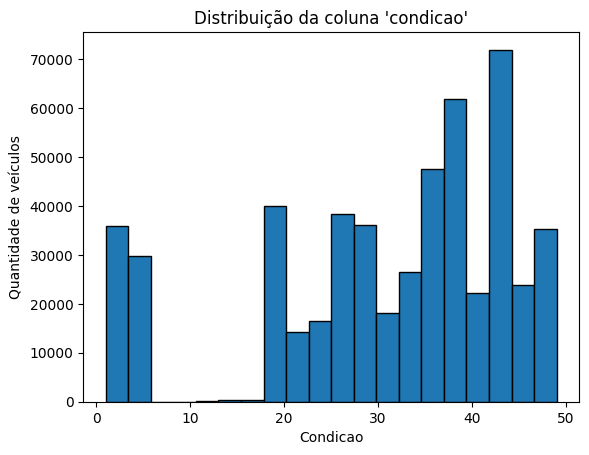

In [525]:
import matplotlib.pyplot as plt

plt.hist(df_silver["condicao"], bins=20, edgecolor='black')
plt.title("Distribuição da coluna 'condicao'")
plt.xlabel("Condicao")
plt.ylabel("Quantidade de veículos")
plt.show()

In [526]:
def classificar_condicao(df, coluna_condicao="condicao", labels=None):
    df = df.copy()
    if labels is None:
        labels = ["Muito ruim", "Ruim", "Regular", "Boa", "Excelente"]

    # Calcular percentiles
    percentis = df[coluna_condicao].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

    # Crear columna categórica
    df["condicao_categoria"] = pd.cut(
        df[coluna_condicao],
        bins=percentis,
        labels=labels,
        include_lowest=True
    )

    return df

In [527]:
df_silver = classificar_condicao(df_silver, coluna_condicao="condicao")

conteo = df_silver["condicao_categoria"].value_counts().sort_index()


porcentaje = (conteo / conteo.sum() * 100).round(2)


resumen_condicao = pd.DataFrame({
    "Condicao": conteo.index,
    "Cantidad": conteo.values,
    "Porcentaje (%)": porcentaje.values
})

display(resumen_condicao)


,Condicao,Cantidad,Porcentaje (%)
0,Muito ruim,106567,21
1,Ruim,105114,20
2,Regular,116946,23
3,Boa,106550,21
4,Excelente,83592,16


=====================
# Coluna odometro
=====================


In [528]:
def validar_odometro(df, coluna='odometro'):

    df_temp = df.copy()
    df_temp[coluna] = pd.to_numeric(df_temp[coluna], errors='coerce')

    negativos = df_temp[df_temp[coluna] < 0]

    return negativos



In [529]:
def limpar_odometro(df, coluna='odometro', max_valor=999999):

    df = df.copy()

    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

    df = df[df[coluna].notna()]
    df = df[df[coluna] >= 0]
    df = df[df[coluna] <= max_valor]

    return df

In [530]:
validar_odometro(df_silver, coluna='odometro')

total_inicial = len(dfsilver)

df_silver = limpar_odometro(df_silver, coluna='odometro')

total_final = len(df_silver)

eliminados = total_inicial - total_final

resumen_odometro = pd.DataFrame([{
    "Registros iniciales": total_inicial,
    "Registros eliminados": eliminados,
    "% eliminados": round(eliminados / total_inicial * 100, 2),
    "Registros finales": total_final,
    "% restantes": round(total_final / total_inicial * 100, 2)
}])

resumen_odometro

,Registros iniciales,Registros eliminados,% eliminados,Registros finales,% restantes
0,558837,29115,5,529722,95


=====================
# Coluna preco_mmr
=====================


In [531]:
def limpar_preco_mmr(df, coluna_preco="preco_mmr"):

    df = df.copy()

    df = df[df[coluna_preco].notna()]
    df = df[df[coluna_preco] >= 0]

    return df

In [532]:
df_silver["diferenca_preco"] = df_silver["preco_venda"] - df_silver["preco_mmr"]

In [533]:

total_inicial = dfsilver.shape[0]

df_silver = limpar_preco_mmr(df_silver, 'preco_mmr')

total_final = df_silver.shape[0]
eliminados = total_inicial - total_final

df_eliminados = pd.DataFrame([{
    "Registros iniciales": total_inicial,
    "Registros eliminados (preco_mmr nulo)": eliminados,
    "Registros finales": total_final
}])

df_eliminados

,Registros iniciales,Registros eliminados (preco_mmr nulo),Registros finales
0,558837,29127,529710


In [534]:
print("--------------------------------")
print("Resumen estadístico de preco_mmr")
print("--------------------------------")

resumo = df_silver["preco_mmr"].describe().round(2)

df_resumo = pd.DataFrame([resumo])

df_resumo

--------------------------------
Resumen estadístico de preco_mmr
--------------------------------


,count,mean,std,min,25%,50%,75%,max
preco_mmr,"529,710","13,874","9,636",25,"7,325","12,400","18,400","182,000"


In [535]:
# Percentiles e IQR
Q1 = df_silver["preco_mmr"].quantile(0.25)
Q3 = df_silver["preco_mmr"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers_df = df_silver[
    (df_silver["preco_mmr"] < limite_inferior) |
    (df_silver["preco_mmr"] > limite_superior)
].copy()

# DataFrame horizontal
resumen_outliers = pd.DataFrame([{
    "Q1": round(Q1, 2),
    "Q3": round(Q3, 2),
    "IQR": round(IQR, 2),
    "Limite inferior": round(limite_inferior, 2),
    "Limite superior": round(limite_superior, 2),
    "Cantidad de outliers": len(outliers_df),
    "% outliers": round(len(outliers_df) / len(df_silver) * 100, 2)
}])

# Mostrar
resumen_outliers


,Q1,Q3,IQR,Limite inferior,Limite superior,Cantidad de outliers,% outliers
0,"7,325","18,400","11,075","-9,288","35,012",15478,3


In [536]:
marca_preco = df_silver.groupby("marca")["preco_mmr"].agg(
    unidades="count",
    preco_promedio="mean",
    preco_mediana="median",
    preco_min="min",
    preco_max="max"
).sort_values(by="preco_promedio")


marca_preco_format = marca_preco.copy()


for col in ["preco_promedio", "preco_mediana", "preco_min", "preco_max"]:
    marca_preco_format[col] = marca_preco_format[col].apply(lambda x: f"${x:,.2f}")


display(marca_preco_format)

,unidades,preco_promedio,preco_mediana,preco_min,preco_max
marca,,,,,
Daewoo,2,$487.50,$487.50,$475.00,$500.00
Geo,19,$609.21,$575.00,$275.00,$950.00
Oldsmobile,362,"$1,091.57","$1,050.00",$25.00,"$3,225.00"
Isuzu,198,"$1,753.66","$1,400.00",$300.00,"$6,475.00"
Suzuki,889,"$3,471.12","$2,850.00",$225.00,"$15,150.00"
Saturn,2781,"$3,492.84","$2,800.00",$25.00,"$13,700.00"
Saab,476,"$3,750.05","$3,125.00",$25.00,"$14,950.00"
Pontiac,4372,"$3,957.85","$3,650.00",$50.00,"$30,600.00"
Mercury,1958,"$4,091.64","$3,437.50",$50.00,"$16,500.00"


=======================
# Coluna preco_venda
======================


In [537]:
def limpar_preco_venda(df, coluna_preco="preco_venda"):

    df = df.copy()
    total_inicial = len(df)

    df = df[df[coluna_preco].notna()]

    df = df[df[coluna_preco] > 0]

    return df

In [538]:
df_silver = limpar_preco_venda(df_silver, 'preco_venda')

In [539]:
resumo = df_silver["preco_venda"].describe().round(2)

df_resumo = pd.DataFrame([resumo])

df_resumo

,count,mean,std,min,25%,50%,75%,max
preco_venda,"529,710","13,712","9,703",1,"7,100","12,250","18,300","230,000"


In [540]:
df_silver["preco_venda"].median()

12250.0

=====================
# Coluna data_venda
=====================


In [541]:
def limpar_data_venda(df, coluna_data="data_venda"):
    df = df.copy()


    df[coluna_data] = pd.to_datetime(
    df[coluna_data].str.replace(r" GMT.*", "", regex=True),
    format="%a %b %d %Y %H:%M:%S",
    errors="coerce"
)

    # Eliminar registros nulos o inválidos
    df = df[df[coluna_data].notna()].copy()

    # Ahora sí, crear columnas de año y mes
    df["ano_venda"] = df[coluna_data].dt.year
    df["mes_venda"] = df[coluna_data].dt.month

    return df

In [542]:
df_silver = limpar_data_venda(df_silver)

In [543]:
total_linhas = len(df_silver)

df_info = pd.DataFrame({
    "Coluna": df_silver.columns,
    "Não Nulos": df_silver.notna().sum().values,
    "Nulos": df_silver.isna().sum().values,
    "% Nulos": (df_silver.isna().sum().values / total_linhas * 100).round(2)
})

df_info.index = range(1, len(df_info) + 1)

df_info

,Coluna,Não Nulos,Nulos,% Nulos
1,chassi,529710,0,0
2,ano,529710,0,0
3,marca,529710,0,0
4,modelo,529710,0,0
5,carroceria,529710,0,0
6,estado,529710,0,0
7,condicao,518739,10971,2
8,odometro,529710,0,0
9,preco_mmr,529710,0,0
10,preco_venda,529710,0,0


In [544]:
print(df_silver.shape)

(529710, 16)


=================================
# Comparação de Modelos
=================================

In [545]:
ranking_modelos = (
    df_silver
    .groupby(['marca', 'modelo'], as_index=False)
    ['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Total_Ventas'})
)

ranking_modelos_bajas = ranking_modelos_bajas.sort_values(by='Total_Ventas', ascending=True).reset_index(drop=True)

print("=================================")
print("Ranking de Vendas por Modelo:")
print("=================================")
ranking_modelos_bajas.head(10)

Ranking de Vendas por Modelo:


,marca,modelo,Total_Ventas
0,Toyota,Paseo,150
1,Dodge,Spirit,300
2,Oldsmobile,Regency,300
3,Cadillac,Fleetwood,350
4,Chevrolet,Corsica,350
5,Geo,Metro,400
6,Honda,Civic Del Sol,450
7,Oldsmobile,Achieva,500
8,Audi,Cabriolet,800
9,Daewoo,Nubira,900


In [546]:
# =================================
# Receita Total por Modelos
# =================================

receita_modelos = (
    df_silver
    .groupby('modelo', as_index=False)['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Receita_Total'})
    .sort_values(by='Receita_Total', ascending=False)
    .reset_index(drop=True)
)

print("=================================")
print("Receita Total por Modelos:")
print("================================")
receita_modelos.head(10)

Receita Total por Modelos:


,modelo,Receita_Total
0,F-150,"260,022,309"
1,Altima,"218,929,608"
2,Escape,"160,807,352"
3,Fusion,"156,951,320"
4,G Sedan,"146,519,056"
5,Camry,"138,527,183"
6,Explorer,"137,461,444"
7,3 Series,"133,405,080"
8,Edge,"105,641,957"
9,Silverado 1500,"103,886,436"


In [547]:
# =================================
# Preço médio de Vendas
# =================================

# Agrupar por modelo y calcular el precio promedio
preco_medio_modelos = (
    df_silver
    .groupby('modelo', as_index=False)['preco_venda']
    .mean()
    .rename(columns={'preco_venda': 'Preco_Medio'})
    .sort_values(by='Preco_Medio', ascending=False)  # ordenar de mayor a menor precio
    .reset_index(drop=True)
)

# Mostrar top 10 modelos con mayor precio promedio
preco_medio_modelos.head(10)

,modelo,Preco_Medio
0,458 Italia,"183,000"
1,Sls Amg Gt,"156,500"
2,I8,"156,188"
3,Flying Spur,"154,000"
4,Ghost,"153,488"
5,California,"131,846"
6,Sls Amg,"116,017"
7,Gallardo,"112,625"
8,Continental Gtc Speed,"111,000"
9,F430,"109,750"


=================================
# Comparação de Marcas
=================================

In [548]:
ranking_marcas = (
    df_silver
    .groupby('marca', as_index=False)
    .agg(
        quantidade_vendida=('preco_venda', 'count'),
        total_vendas=('preco_venda', 'sum')
    )
)
# Ordenar por menor receita (low performance)
ranking_marcas = ranking_marcas.sort_values(by='total_vendas', ascending=True).reset_index(drop=True)

print("=================================")
print("Ranking de Vendas por Marca:")
print("=================================")
ranking_marcas.head(10)

Ranking de Vendas por Marca:


,marca,quantidade_vendida,total_vendas
0,Daewoo,2,900
1,Geo,19,"10,050"
2,Lotus,1,"40,800"
3,Plymouth,20,"191,850"
4,Isuzu,198,"337,376"
5,Oldsmobile,362,"344,425"
6,Fisker,9,"418,150"
7,Lamborghini,4,"450,500"
8,Aston Martin,25,"1,370,300"
9,Tesla,23,"1,542,250"


=================================
# Análise Regional
=================================

In [549]:
pd.options.display.float_format = '{:,.0f}'.format

vendas_por_regiao = (
    df_silver
    .groupby('region', as_index=False)['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Total_Vendas'})
    .sort_values(by='Total_Vendas', ascending=False)
    .reset_index(drop=True)
)

print("=================================")
print("Vendas por Região:")
print("=================================")

vendas_por_regiao

Vendas por Região:


,region,Total_Vendas
0,South,"2,922,867,221"
1,North,"1,978,741,730"
2,West,"1,452,106,039"
3,Midwest,"909,823,258"


In [550]:
ranking_modelos_estado = (
    df_silver
    .groupby(['region','modelo'], as_index=False)['preco_venda']
    .sum()
    .rename(columns={'preco_venda': 'Total_Vendas'})
    .sort_values(['region','Total_Vendas'], ascending=[True, False])
    .reset_index(drop=True)
)

print ("=================================")
print ("Ranking de modelos por Região")
print ("=================================")

ranking_modelos_estado.head(20)

Ranking de modelos por Região


,region,modelo,Total_Vendas
0,Midwest,Escape,"44,219,602"
1,Midwest,F-150,"41,808,945"
2,Midwest,Fusion,"39,114,558"
3,Midwest,Altima,"33,398,197"
4,Midwest,Explorer,"28,264,878"
5,Midwest,Edge,"25,083,826"
6,Midwest,G Sedan,"22,359,630"
7,Midwest,Focus,"20,717,086"
8,Midwest,Town & Country,"17,216,047"
9,Midwest,Grand Caravan,"16,220,516"


In [551]:
# =================================
# Comparação de preço médio entre estados
# =================================

preco_medio_estado = (
    df_silver
    .groupby('region', as_index=False)['preco_venda']
    .mean()
    .rename(columns={'preco_venda': 'Preco_Medio'})
    .sort_values(by='Preco_Medio', ascending=False)
)


print ("=================================")
print ("Comparação de preço médio entre Região")
print ("=================================")

preco_medio_estado

Comparação de preço médio entre Região


,region,Preco_Medio
1,North,"14,458"
0,Midwest,"14,378"
3,West,"14,304"
2,South,"12,817"


=======================
# Pipeline
=======================


In [552]:
from IPython.display import display, HTML

def print_color(msg, color="black"):
    display(HTML(f"<span style='color:{color}; font-weight:bold'>{msg}</span>"))

def pipeline_limpieza(df, mostrar_resumen=True):

    df_silver = df.copy()

    df_silver = df_silver[[
        "vin","year","make","model","body","state",
        "condition","odometer","mmr","sellingprice","saledate"
    ]].rename(columns={
        "vin": "chassi",
        "year": "ano",
        "make": "marca",
        "model": "modelo",
        "body": "carroceria",
        "state": "estado",
        "condition": "condicao",
        "odometer": "odometro",
        "mmr": "preco_mmr",
        "sellingprice": "preco_venda",
        "saledate": "data_venda"
    })

    if mostrar_resumen:
        print_color("Colunas selecionadas e renomeadas", "green")

    # 🔹 VIN
    df_silver = limpar_vin(df_silver, coluna_chassi='chassi')
    if mostrar_resumen:
        print_color(f"Chassi limpo | Registros: {len(df_silver)}", "green")

    # 🔹 ANO
    validar_ano(df_silver, ano_col='ano')
    df_silver = limpar_ano(df_silver, ano_col='ano')
    if mostrar_resumen:
        print_color(f"Ano validado e limpo | Registros: {len(df_silver)}", "green")

    # 🔹 MARCAS
    df_silver = tratamento_marcas(df_silver, col_coluna='marca')
    if mostrar_resumen:
        print_color("Marcas normalizadas", "green")

    # 🔹 CARROCERIA
    df_silver = limpar_carroceria(df_silver, coluna='carroceria')
    if mostrar_resumen:
        print_color(f"Carroceria normalizada | Categorias: {df_silver['carroceria'].nunique()}", "green")

    # 🔹 MODELO
    df_silver = limpar_modelo(df_silver)
    if mostrar_resumen:
        print_color("Modelos normalizados", "green")

    # 🔹 ESTADOS
    df_silver = limpar_estados(df_silver)
    if mostrar_resumen:
        print_color(f"Estados tratados | Estados únicos: {df_silver['estado'].nunique()}", "green")

    # 🔹 CONDIÇÃO
    df_silver = classificar_condicao(df_silver, coluna_condicao='condicao')
    if mostrar_resumen:
        print_color("Condição classificada", "green")
        print_color("Distribuição da condição:", "blue")

    display(df_silver['condicao_categoria'].value_counts())

    # 🔹 ODÔMETRO
    validar_odometro(df_silver, coluna='odometro')
    df_silver = limpar_odometro(df_silver)
    if mostrar_resumen:
        print_color(f"Odômetro limpo | Registros: {len(df_silver)}", "green")

    # 🔹 PREÇO
    df_silver = limpar_preco_venda(df_silver, coluna_preco='preco_venda')
    if mostrar_resumen:
        print_color(f"Preço de venda limpo | Registros: {len(df_silver)}", "green")

    # 🔹 DATA
    df_silver = limpar_data_venda(df_silver, coluna_data='data_venda')
    if mostrar_resumen:
        print_color("Data de venda tratada", "green")

    return df_silver

df_silver = pipeline_limpieza(df_bronze, mostrar_resumen=True)

,count
condicao_categoria,
Regular,116946
Muito ruim,106567
Boa,106550
Ruim,105114
Excelente,83592


================================
#Crear Camada Silver
================================


In [553]:
# Guardar como CSV
df_silver.to_csv("car_prices_silver.csv", index=False)

In [554]:
df_silver.head()

,chassi,ano,marca,modelo,carroceria,estado,condicao,odometro,preco_mmr,preco_venda,data_venda,region,condicao_categoria,ano_venda,mes_venda
0,5XYKTCA69FG566472,2015,Kia,Sorento,SUV,CA,5,"16,639","20,500","21,500",2014-12-16 12:30:00,West,Muito ruim,2014,12
1,5XYKTCA69FG561319,2015,Kia,Sorento,SUV,CA,5,"9,393","20,800","21,500",2014-12-16 12:30:00,West,Muito ruim,2014,12
2,WBA3C1C51EK116351,2014,Bmw,3 Series,Sedan,CA,45,"1,331","31,900","30,000",2015-01-15 04:30:00,West,Excelente,2015,1
3,YV1612TB4F1310987,2015,Volvo,S60,Sedan,CA,41,"14,282","27,500","27,750",2015-01-29 04:30:00,West,Boa,2015,1
4,WBA6B2C57ED129731,2014,Bmw,6 Series Gran Coupe,Sedan,CA,43,"2,641","66,000","67,000",2014-12-18 12:30:00,West,Boa,2014,12


================================
# Camada Gold
================================



In [555]:
df_gold = df_silver.copy()

In [556]:
total_preco_venda = df_gold['preco_venda'].sum()
print(total_preco_venda)

7263538248.0


In [557]:
df_filtrado = df_gold[df_gold["ano_venda"].isin([2014, 2015])]

total_vendas_geral = df_filtrado.shape[0]
total_receita_geral = df_filtrado["preco_venda"].sum()

gold_marca = df_filtrado.groupby("marca").agg(
    vendas_marca=("preco_venda", "count"),
    receita_marca=("preco_venda", "sum")
).reset_index()

gold_marca["participacao_vendas"] = (
    gold_marca["vendas_marca"] / total_vendas_geral * 100
)

gold_marca["participacao_receita"] = (
    gold_marca["receita_marca"] / total_receita_geral * 100
)


gold_marca = gold_marca.sort_values("receita_marca", ascending=True)


gold_marca["participacao_receita_acumulada"] = gold_marca["participacao_receita"].cumsum()

gold_marca = gold_marca.round(2)

gold_marca.to_csv("gold_analisis_marca_pareto.csv", index=False)

gold_marca.head(10)

,marca,vendas_marca,receita_marca,participacao_vendas,participacao_receita,participacao_receita_acumulada
9,Daewoo,2,900,0,0,0
15,Geo,19,"10,050",0,0,0
29,Lotus,1,"40,800",0,0,0
38,Plymouth,20,"191,850",0,0,0
21,Isuzu,198,"337,376",0,0,0
37,Oldsmobile,362,"344,425",0,0,0
13,Fisker,9,"418,150",0,0,0
25,Lamborghini,4,"450,500",0,0,0
1,Aston Martin,25,"1,370,300",0,0,0
49,Tesla,23,"1,542,250",0,0,0


In [558]:

df_gold.to_csv("car_prices_gold.csv", index=False)

resumen_kpis = pd.DataFrame({
    "Indicador": ["Total de vendas", "Receita total", "Preço médio"],
    "Valor": [len(df_gold), df_gold['preco_venda'].sum(), df_gold['preco_venda'].mean()]
})

resumen_kpis["Valor"] = resumen_kpis["Valor"].apply(lambda x: "${:,.2f}".format(x) if isinstance(x, (int,float)) else x)
resumen_kpis.to_csv("gold_kpis_gerais.csv", index=False)

vendas_ano = df_gold.groupby('ano_venda')['preco_venda'].count().reset_index()
vendas_ano.rename(columns={'preco_venda': 'vendas_acumuladas'}, inplace=True)
vendas_ano.to_csv("gold_vendas_ano.csv", index=False)

vendas_modelo = df_gold.groupby('modelo').agg(
    total_vendas=('preco_venda', 'count'),
    receita_total=('preco_venda', 'sum'),
    preco_medio=('preco_venda', 'mean')
).reset_index()

vendas_modelo["receita_total"] = vendas_modelo["receita_total"].map("${:,.2f}".format)
vendas_modelo["preco_medio"] = vendas_modelo["preco_medio"].map("${:,.2f}".format)
vendas_modelo.to_csv("gold_vendas_modelo.csv", index=False)


vendas_mes = df_gold.groupby(['ano_venda', 'mes_venda']).agg(
    total_vendas=('preco_venda', 'count'),
    receita_total=('preco_venda', 'sum')
).reset_index()

vendas_mes["receita_total"] = vendas_mes["receita_total"].map("${:,.2f}".format)
vendas_mes.to_csv("gold_vendas_mes.csv", index=False)

vendas_estado = df_gold.groupby('estado').agg(
    total_vendas=('preco_venda', 'count'),
    receita_total=('preco_venda', 'sum'),
    preco_medio=('preco_venda', 'mean')
).reset_index()

vendas_estado["receita_total"] = vendas_estado["receita_total"].map("${:,.2f}".format)
vendas_estado["preco_medio"] = vendas_estado["preco_medio"].map("${:,.2f}".format)
vendas_estado.to_csv("gold_vendas_estado.csv", index=False)

preco_medio_marca = df_gold.groupby("marca")["preco_venda"].agg(
    total_vendas="count",
    preco_medio="mean"
).sort_values("total_vendas", ascending=False).reset_index()

preco_medio_marca["preco_medio"] = preco_medio_marca["preco_medio"].map("${:,.2f}".format)
preco_medio_marca.to_csv("gold_preco_medio_marca.csv", index=False)

receita_marca = df_gold.groupby("marca")["preco_venda"].agg(
    total_vendas="count",
    receita_total="sum",
    preco_medio="mean"
).sort_values("receita_total", ascending=False).reset_index()

receita_marca["receita_total"] = receita_marca["receita_total"].map("${:,.2f}".format)
receita_marca["preco_medio"] = receita_marca["preco_medio"].map("${:,.2f}".format)
receita_marca.to_csv("gold_receita_marca.csv", index=False)

baixa_performance = receita_marca.sort_values("total_vendas").head(10)
baixa_performance.to_csv("gold_baixa_performance.csv", index=False)

df_gold["faixa_quilometragem"] = pd.cut(
    df_gold["odometro"],
    bins=[0, 50000, 100000, 150000, 200000, 300000],
    labels=["0-50k", "50k-100k", "100k-150k", "150k-200k", "200k+"]
)
preco_km = df_gold.groupby("faixa_quilometragem", observed=False).agg(
    preco_medio_venda=("preco_venda", "mean"),
    total_vendas=("preco_venda", "count")
).reset_index()

preco_km["preco_medio_venda"] = preco_km["preco_medio_venda"].map("${:,.2f}".format)
preco_km.to_csv("gold_preco_por_quilometragem.csv", index=False)

df_gold["diferenca_preco"] = df_gold["preco_venda"] - df_gold["preco_mmr"]

total_registros_val = df_gold["diferenca_preco"].count()
vendas_abaixo_mmr_val = (df_gold["diferenca_preco"] < 0).sum()

percentual_mmr = pd.DataFrame({
    "total_registros": [total_registros_val],
    "vendas_abaixo_mmr": [vendas_abaixo_mmr_val]
})

percentual_mmr["percentual_abaixo_mmr"] = (
    percentual_mmr["vendas_abaixo_mmr"] / percentual_mmr["total_registros"] * 100
).round(2)

percentual_mmr.to_csv("gold_percentual_vendas_abaixo_mmr.csv", index=False)

vendas_ytd = df_gold.groupby(['ano_venda','mes_venda']).agg(
    vendas_mes=('preco_venda','count'),
    receita_mes=('preco_venda','sum')
).reset_index()

vendas_ytd["vendas_ytd"] = vendas_ytd.groupby("ano_venda")["vendas_mes"].cumsum()
vendas_ytd["receita_ytd"] = vendas_ytd.groupby("ano_venda")["receita_mes"].cumsum()

vendas_ytd.to_csv("gold_vendas_ytd.csv", index=False)

print("...Todos os arquivos Gold foram salvos corretamente...")


...Todos os arquivos Gold foram salvos corretamente...


==================================
##CARREGAMENTO DO BANCO
==================================

In [559]:
from sqlalchemy import create_engine


In [560]:
engine = create_engine('sqlite:///car_prices_final.db')
df_bronze.to_sql('car_prices_bronze', con=engine, if_exists='replace', index=False)
df_silver.to_sql('car_prices_silver', con=engine, if_exists='replace', index=False)
df_gold.to_sql('car_prices_gold', con=engine, if_exists='replace', index=False)

529710

##
